# D1 ? Core size versus velocity
A reproducible power-law study accompanying the proposed forced incompressible Navier?Stokes construction.

**Question:** for an explicit radius/speed reference pair, what radius corresponds to an extreme speed, and which physical screens are crossed first?

This notebook evaluates a scaling surrogate, not a PDE solution. Its default is the inverse-law limit h -> 0+, not an admissible theorem instance. The [article](../../writing/d1_core_size/article.html) provides the narrative; [source notes](../../writing/d1_core_size/source-notes.md) record equations, provenance and calibration limits.

Run all cells from a fresh kernel. No network or random inputs are needed.

In [1]:
from pathlib import Path
import sys
import numpy as np
import sympy as sp
from IPython.display import Markdown, display, Image

repo = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "code/d1_core_size/parameters.json").is_file())
sys.path.insert(0, str(repo / "code/src"))
from nscomp.scaling import CoreScaling, exponent_envelope
from nscomp.d1 import (load_parameters, derived, reference_model, generate,
                      speed_table, length_table, fluid_table, gradient_rows,
                      markdown_table)
p = load_parameters()
d = derived(p)
model = reference_model(p)
display(Markdown(f"Reference: **r0 = {model.r0_m:g} m**, **U0 = {model.u0_m_s:g} m/s**. "
                 f"Baseline h = {model.h:g}, an inverse-law limiting proxy."))

Reference: **r0 = 0.001 m**, **U0 = 1 m/s**. Baseline h = 0, an inverse-law limiting proxy.

## 1. Derive the exponent independently
Let s = log(tau/tau0). The logarithmic radius is s/2, while logarithmic speed is -(1/2+h)s. Dividing their derivatives gives the logarithmic slope of radius against speed.

The source gives characteristic scales up to positive factors. The anchored equality used below is our leading-order surrogate.

In [2]:
s, h = sp.symbols("s h", real=True)
slope = sp.simplify(sp.diff(s/2, s) / sp.diff(-(sp.Rational(1, 2)+h)*s, s))
display(sp.Eq(sp.Symbol("slope"), slope))
assert sp.simplify(slope + 1/(1+2*h)) == 0

# Independent time parameterization of the normalized power laws.
tau_ratio = np.geomspace(1e-24, 1, 81)
h_demo = 1e-6  # illustrative small h, not a verified full-profile instance
check_model = CoreScaling(model.r0_m, model.u0_m_s, h_demo)
speeds = model.u0_m_s * tau_ratio**(-0.5-h_demo)
np.testing.assert_allclose(check_model.radius(speeds),
                           model.r0_m*np.sqrt(tau_ratio), rtol=2e-14)
print("Symbolic slope and independent time parameterization agree.")

Eq(slope, -1/(2*h + 1))

Symbolic slope and independent time parameterization agree.


## 2. Audit the parameter h
The introductory interval is 0<h<0.01. Lemma 4.8 additionally requires h<exp(-T_d) with T_d=exp(M_d)+10, hence h<exp(-10). This is only a necessary ceiling.

The h=0 endpoint is a limiting proxy. The broad h sweep in the data intentionally explores the introductory range, including values that exceed the detailed ceiling. It is not a family of verified constructed solutions.

In [3]:
target_speed = .01*p["constants"]["speed_of_light_m_s"]
cap = d["necessary_h_ceiling"]
lo, hi = exponent_envelope(target_speed, model.r0_m, model.u0_m_s, cap)
display(Markdown(f"Necessary ceiling: **h < {cap:.8g}**. "
                 f"At 0.01c, exponent-only interval at this fixed anchor: "
                 f"**{1e9*lo:.6f} to {1e9*hi:.6f} nm**. "
                 f"This excludes unknown normalization errors."))

Necessary ceiling: **h < 4.539993e-05**. At 0.01c, exponent-only interval at this fixed anchor: **0.333564 to 0.334016 nm**. This excludes unknown normalization errors.

## 3. Reproduce the data and figures
All main calculations use SI units. The reference pair is not matched to the paper's dimensionless profile and viscosity. In particular r0*U0/nu must equal the profile's corresponding dimensionless product when nu_hat=1.

The two fluid columns below are reference states, not simulated thermodynamic trajectories. The same radius-speed curve is compared with both.

In [4]:
summary = generate()
display(Markdown(fluid_table(p)))
print("Reference Reynolds products:",
      f"air={summary['air_reference_reynolds']:.3g},",
      f"water={summary['water_reference_reynolds']:.3g}")
print("Profile/viscosity compatibility established:",
      summary["profile_viscosity_compatibility_established"])

| Reference property | Air | Liquid water |
| --- | --- | --- |
| Temperature / pressure | 296.15 K / 101.3 kPa | 298.15 K / 100 kPa |
| Density (kg/m³) | 1.192 (ideal gas) | 997.047 |
| Sound speed (m/s) | 345 (ideal gas) | 1496.7 |
| Kinematic viscosity (m²/s) | 1.538e-05 | 8.926e-07 |
| Mean spacing n^(-1/3) | 3.43 nm | 311 pm |
| Mean free path | 67.3 nm | Not assigned a dilute-gas value |

Reference Reynolds products: air=65, water=1.12e+03
Profile/viscosity compatibility established: False


| Speed marker | Speed (m/s) | Core radius, inverse-law limit |
| --- | --- | --- |
| Air Ma=0.3 screen | 103.5 | 9.66 µm |
| Air Ma=1 | 345 | 2.9 µm |
| Air Ma=5 marker | 1725 | 580 nm |
| Water Ma=0.3 screen | 449 | 2.23 µm |
| Water Ma=1 marker | 1497 | 668 nm |
| 1 km/s | 1000 | 1 µm |
| 0.01c (formal) | 2.998e+06 | 334 pm |
| 0.1c (formal) | 2.998e+07 | 33.4 pm |

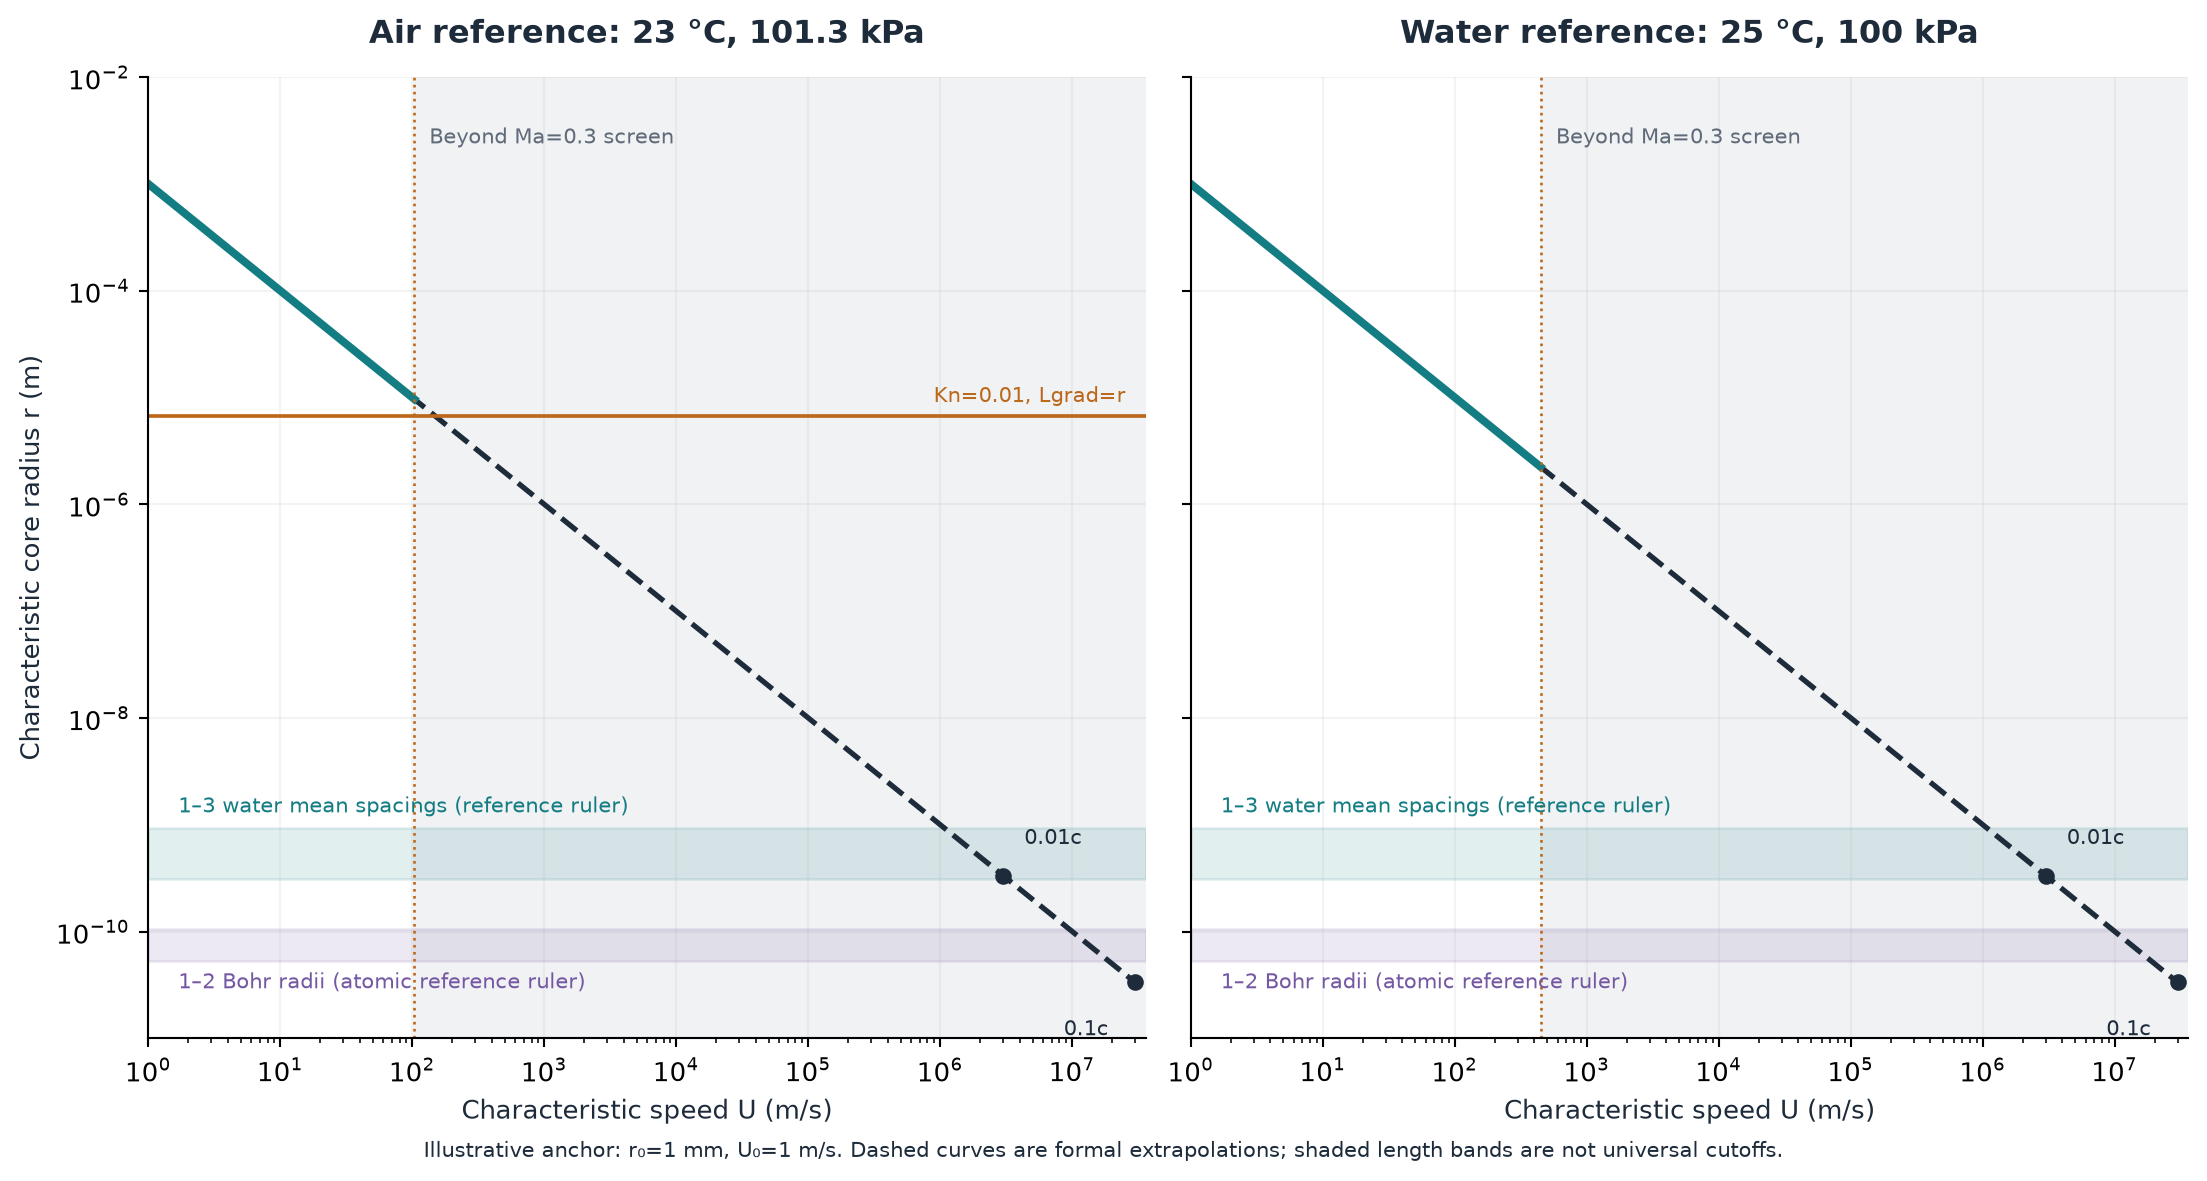

In [5]:
display(Markdown(speed_table(p)))
display(Image(filename=str(repo / "writing/d1_core_size/figures/02_core_size_and_physical_scales.png")))

## 4. Invert the relation at microscopic length scales
All listed lengths are used as a radius/variation-length ruler, not silently as a diameter. Water spacing is n^(-1/3), not a molecular diameter. The Bohr radius is an atomic unit of length, not the radius of every atom. Multiples of either are geometric comparisons, not universal continuum failure thresholds.

In [6]:
display(Markdown(length_table(p)))
water_spacing = d["water_mean_spacing_m"]
u_at_spacing = float(model.speed(water_spacing))
recovered_spacing = float(model.radius(u_at_spacing))
np.testing.assert_allclose(recovered_spacing, water_spacing, rtol=1e-14)
print(f"Inverse consistency at water mean spacing: {recovered_spacing:.6g} m")

| Length used as radius | Length | Formal speed (m/s) |
| --- | --- | --- |
| Air Kn=0.01 radius proxy | 6.73 µm | 149 |
| Air mean free path | 67.3 nm | 1.49e+04 |
| Air mean spacing | 3.43 nm | 2.92e+05 |
| 10 water mean spacings | 3.11 nm | 3.22e+05 |
| 3 water mean spacings | 932 pm | 1.07e+06 |
| 1 water mean spacing | 311 pm | 3.22e+06 |
| 1 Bohr radius | 52.9 pm | 1.89e+07 |

Inverse consistency at water mean spacing: 3.10736e-10 m


## 5. Which screen is first depends on the gradient-length proxy
For gas screening use Kn=lambda/Lgrad, with Lgrad=beta*r. Neither beta nor the tensor velocity gradient has been evaluated from a full flow.

The first of these two markers is not necessarily the first physical effect: temperature, pressure, constitutive changes, and correction wavelengths are uncomputed.

| beta | Kn crossing (m/s) | Mach crossing (m/s) | First of these two |
| --- | --- | --- | --- |
| 0.1 | 14.9 | 103 | Kn |
| 1.0 | 149 | 103 | Mach |
| 10.0 | 1.49e+03 | 103 | Mach |

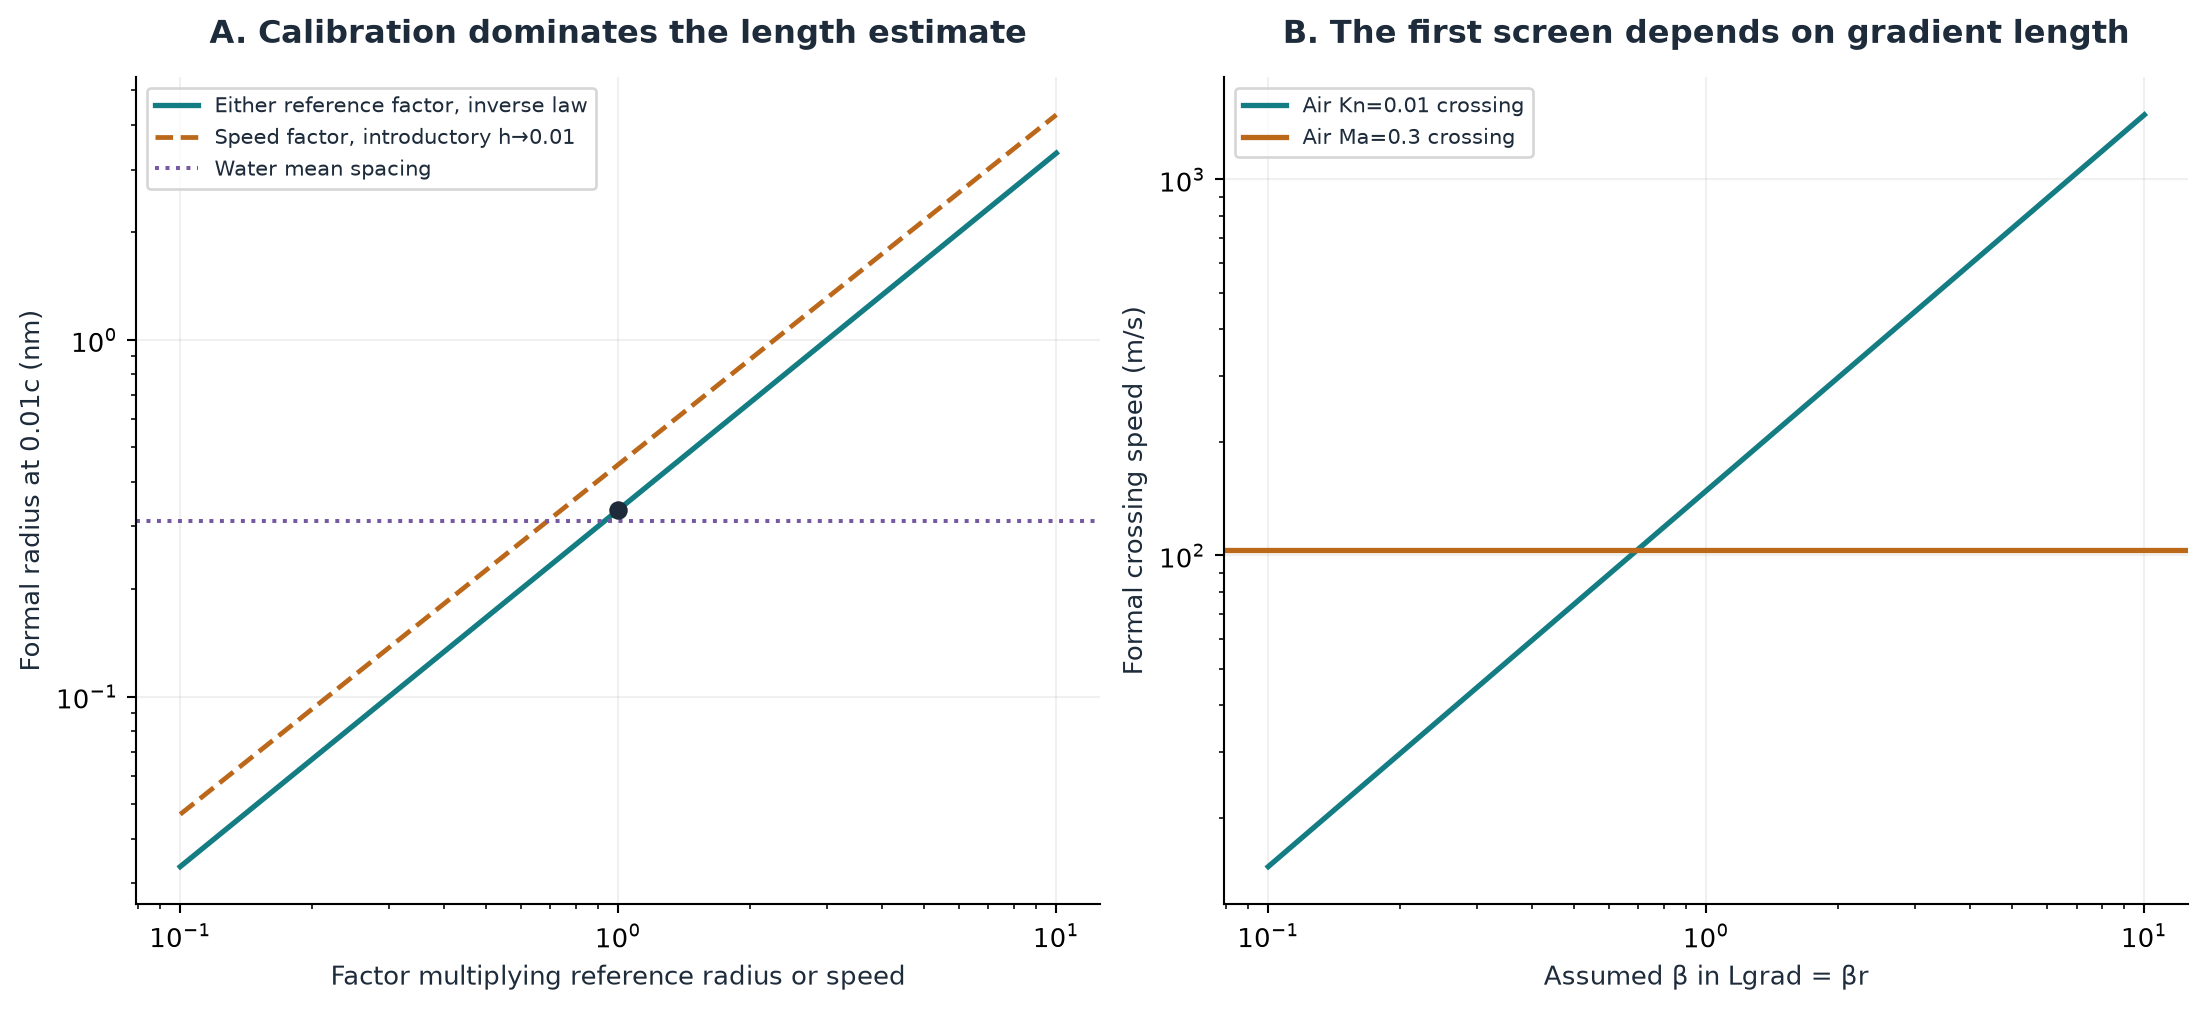

In [7]:
rows = gradient_rows(p)
display(Markdown(markdown_table(
    ["beta", "Kn crossing (m/s)", "Mach crossing (m/s)", "First of these two"],
    [(r["beta"], f'{r["kn_screen_speed_m_s"]:.3g}',
      f'{r["mach_screen_speed_m_s"]:.3g}', r["first_of_two_screens"])
     for r in rows])))
display(Image(filename=str(repo / "writing/d1_core_size/figures/03_calibration_and_gradient_sensitivity.png")))

## 6. Try another calibration without changing the published baseline
Change the numbers in this cell and rerun it. This creates a separate hypothetical reference pair. An unknown radial profile normalization is equivalent to changing r0 and must not be counted as an independent uncertainty.

Do not interpret a new pair as a physical Navier?Stokes solution until the dimensional/profile matching has been established.

0.01c: baseline=0.3336 nm; alternative=0.03336 nm
0.1c: baseline=0.03336 nm; alternative=0.003336 nm


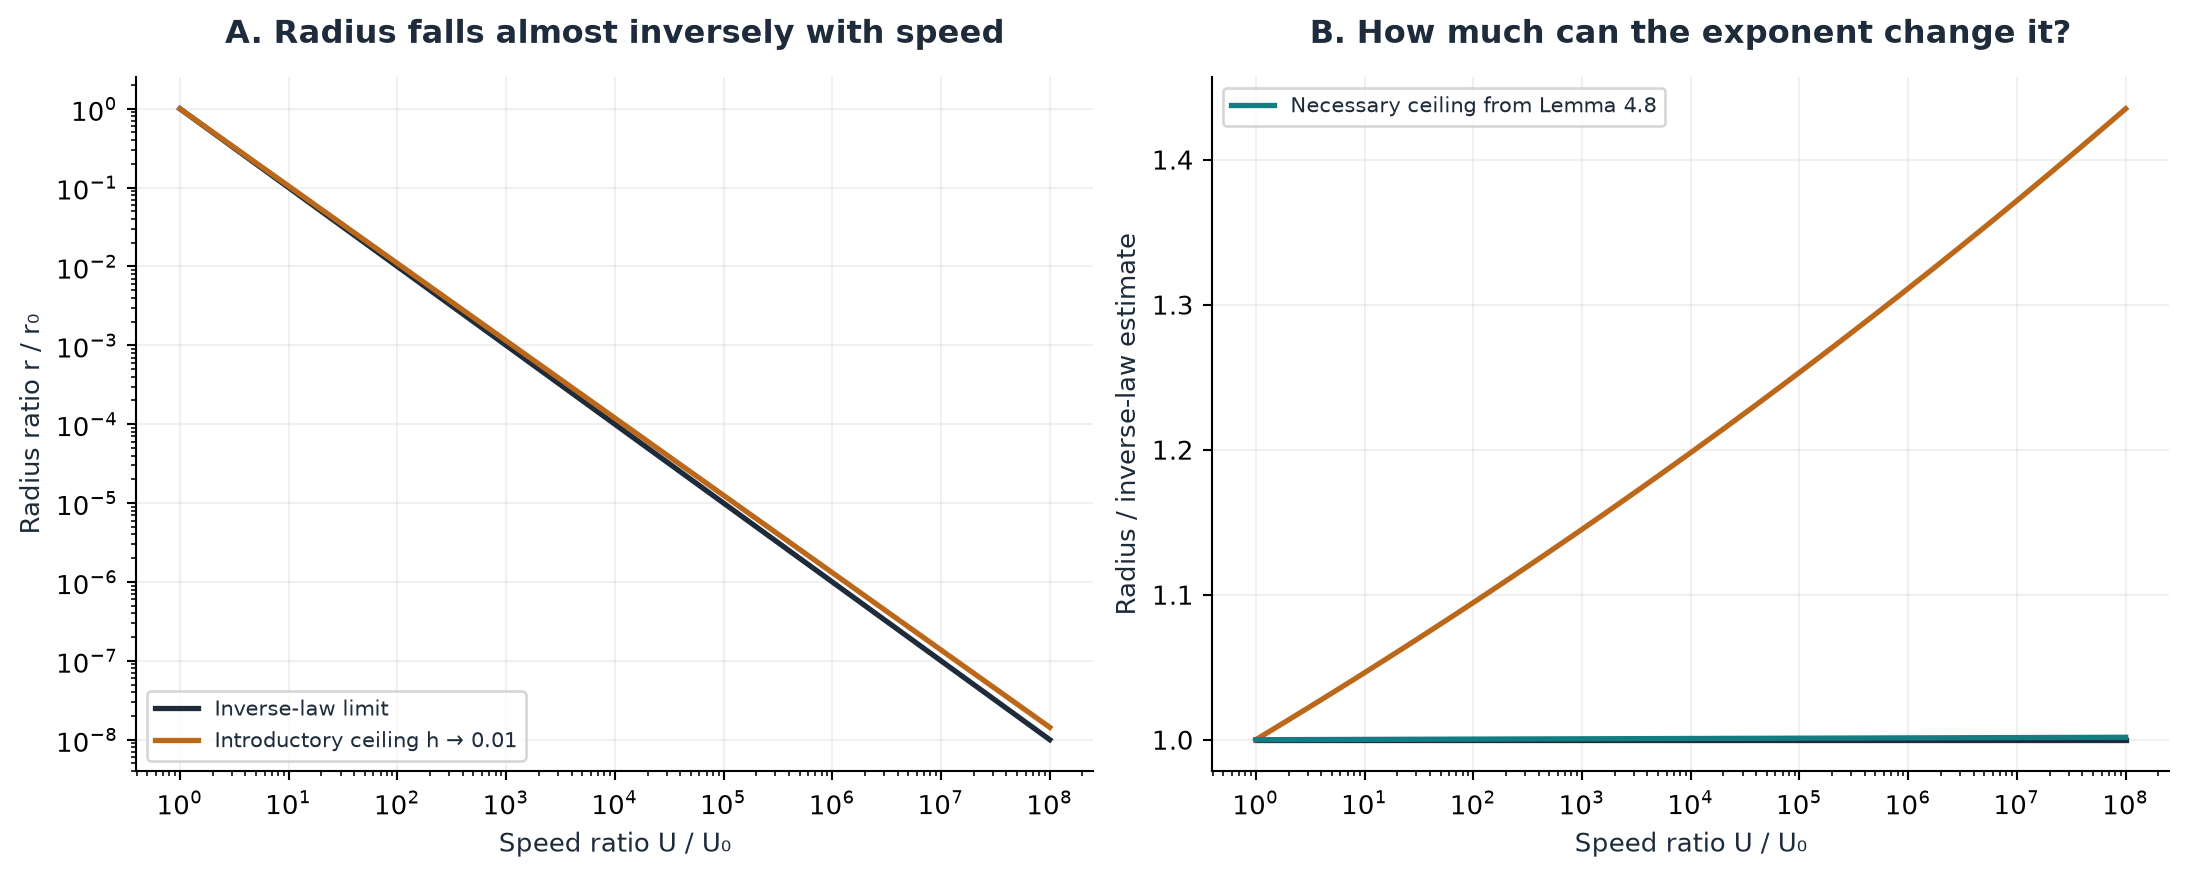

In [8]:
alternative = CoreScaling(r0_m=1e-4, u0_m_s=1.0, h=0.0)
for fraction in [.01, .1]:
    velocity = fraction*p["constants"]["speed_of_light_m_s"]
    print(f"{fraction:g}c: baseline={model.radius(velocity)*1e9:.4g} nm; "
          f"alternative={alternative.radius(velocity)*1e9:.4g} nm")
display(Image(filename=str(repo / "writing/d1_core_size/figures/01_dimensionless_scaling.png")))

## 7. What remains uncomputed
- Actual profile constants and a compatible dimensional realization in a chosen fluid.
- Physical collapse time; exported time ratios are dimensionless.
- The actual velocity gradient, symmetric strain, and correction-pulse scales.
- Pressure/temperature evolution, cavitation, variable constitutive properties and liquid relaxation.
- Dynamical stability or the validity of the infinite proof construction.

There is no CFD mesh in this study. The code checks the power-law algebra and its numerical evaluation; that is not a proof of a Navier?Stokes singularity.

Artifacts: CSV tables and plotting data in data/; figures and article under writing/d1_core_size/. Run code/build.py from the repository root to validate and rebuild this deliverable.